In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=5cd0407e1b5b022dfef52bd3c5642a343ae2a11b9544fe078319d56893127fac
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
import pandas as pd
import numpy as np
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
from google.colab import drive
df1 = '/content/drive/MyDrive/факторный анализ/opros1.csv'

In [ ]:
df = pd.read_csv(df1)
items = df.iloc[:, 1:18]

In [ ]:
chi_square_value, p_value = calculate_bartlett_sphericity(items)
print(f"Тест Бартлетта: chi-square={chi_square_value}, p-value={p_value}")

kmo_all, kmo_model = calculate_kmo(items)
print(f"КМО тест: {kmo_model}")

Тест Бартлетта: chi-square=1226.293403894713, p-value=9.30666889556281e-175
КМО тест: 0.8156603738276405


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


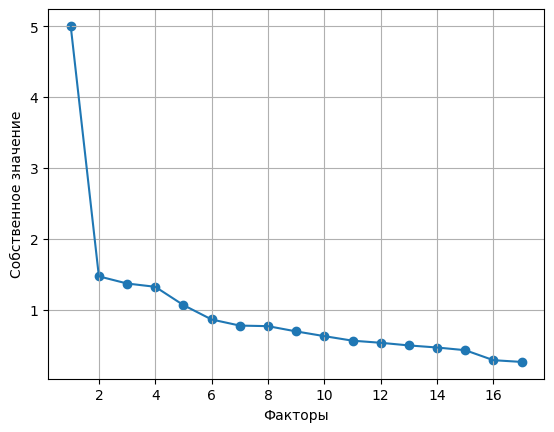

In [ ]:
fa = FactorAnalyzer(rotation=None)
fa.fit(items)

ev, v = fa.get_eigenvalues()

plt.scatter(range(1, items.shape[1]+1), ev)
plt.plot(range(1, items.shape[1]+1), ev)
plt.xlabel('Факторы')
plt.ylabel('Собственное значение')
plt.grid()
plt.show()


In [ ]:
n_factors = 5

fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(items)

loadings = pd.DataFrame(fa.loadings_,
                        index=items.columns,
                        columns=[f"Фактор {i+1}" for i in range(n_factors)])

print(loadings)


                Фактор 1  Фактор 2  Фактор 3  Фактор 4  Фактор 5
acad_scripts    0.282486  0.215671  0.101854  0.155511  0.539313
acad_homework   0.125908  0.149049  0.145979  0.187771  0.519618
acad_logic      0.141435  0.325623  0.142770  0.382155 -0.048241
tutor_speed     0.102291  0.057753  0.841370  0.070751  0.146547
tutor_feedback  0.265131  0.217023  0.250393  0.071495  0.229064
tutor_care      0.136655  0.189019  0.675005  0.190613  0.101285
vk_format       0.515552  0.247013  0.024198  0.153765 -0.000437
vk_quality      0.647467  0.070306  0.113175  0.261016  0.144015
vk_speed        0.794581  0.075740  0.184100  0.048843  0.402720
platf_stable    0.371273  0.321489  0.207197  0.043802  0.255382
platf_easy      0.163647  0.719094 -0.006661  0.032370  0.075786
platf_mobile    0.080648  0.491397  0.020188  0.050913  0.225692
info_org        0.103820  0.569017  0.314087  0.112639  0.074931
info_clear      0.123787  0.466616  0.211248  0.296379  0.132131
psy_stress      0.121561 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


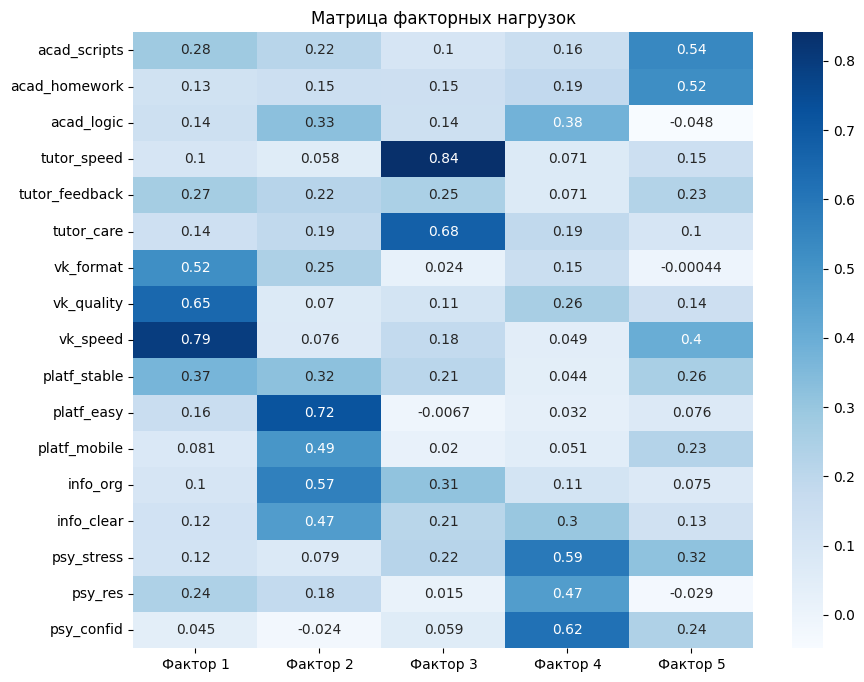

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='Blues')
plt.title('Матрица факторных нагрузок')
plt.show()


In [ ]:
factor_variance = fa.get_factor_variance()
print(pd.DataFrame(factor_variance, index=['Дисперсия', 'Доля дисперсии', 'Накопленная дисперсия']))


                              0         1         2         3         4
Дисперсия              1.804196  1.775797  1.563361  1.404463  1.133487
Доля дисперсии         0.106129  0.104459  0.091962  0.082615  0.066676
Накопленная дисперсия  0.106129  0.210588  0.302550  0.385166  0.451841


          target_recom  target_stay
Фактор_1      0.309371     0.116899
Фактор_2      0.311194     0.190204
Фактор_3      0.135270     0.336723
Фактор_4      0.334431     0.386720
Фактор_5      0.201844     0.357187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


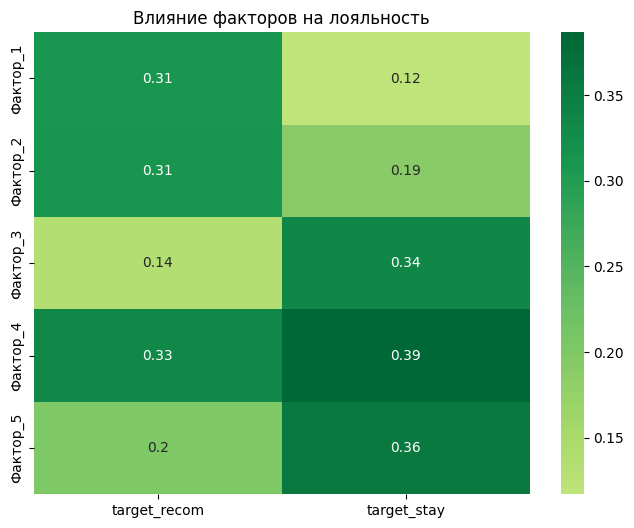

In [ ]:
factor_scores = fa.transform(items)

factor_names = ['Фактор_1', 'Фактор_2', 'Фактор_3', 'Фактор_4', 'Фактор_5']
df_factors = pd.DataFrame(factor_scores, columns=factor_names)

targets = df[['target_recom', 'target_stay']].reset_index(drop=True)

df_corr = pd.concat([df_factors, targets], axis=1)

correlation_matrix = df_corr.corr()

final_corr = correlation_matrix.loc[factor_names, ['target_recom', 'target_stay']]

print(final_corr)

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(final_corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Влияние факторов на лояльность')
plt.show()


In [ ]:
# Для рекомендаций: удалить Фактор_3 и Фактор_5
X_recom_new = df_factors[['Фактор_1', 'Фактор_2', 'Фактор_4']]
X_recom_new_const = sm.add_constant(X_recom_new)
model_recom_new = sm.OLS(y_recom, X_recom_new_const).fit()
print(model_recom_new.summary())

# Для удержания: удалить Фактор_1
X_stay_new = df_factors[['Фактор_2', 'Фактор_3', 'Фактор_4', 'Фактор_5']]
X_stay_new_const = sm.add_constant(X_stay_new)
model_stay_new = sm.OLS(y_stay, X_stay_new_const).fit()
print(model_stay_new.summary())

                            OLS Regression Results                            
Dep. Variable:           target_recom   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     32.05
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.39e-17
Time:                        07:42:15   Log-Likelihood:                -288.99
No. Observations:                 256   AIC:                             586.0
Df Residuals:                     252   BIC:                             600.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.5078      0.047     95.642      0.0

In [ ]:
X = df_factors
y_recom = targets['target_recom']
y_stay = targets['target_stay']
X_const = sm.add_constant(X)

model_recom = sm.OLS(y_recom, X_const).fit()
print("Регрессия: зависимая переменная 'Рекомендация' ")
print(model_recom.summary())

model_stay = sm.OLS(y_stay, X_const).fit()
print("Регрессия: зависимая переменная 'Удержание'")
print(model_stay.summary())

from scipy.stats import zscore

X_std = X.apply(zscore)
X_std_const = sm.add_constant(X_std)
model_recom_std = sm.OLS(zscore(y_recom), X_std_const).fit()
model_stay_std = sm.OLS(zscore(y_stay), X_std_const).fit()

print("Стандартизованные коэффициенты (бета)")
beta_recom = model_recom_std.params[1:]
beta_stay = model_stay_std.params[1:]
beta_df = pd.DataFrame({'Рекомендация (β)': beta_recom, 'Удержание (β)': beta_stay})
print(beta_df.round(3))

Регрессия: зависимая переменная 'Рекомендация' 
                            OLS Regression Results                            
Dep. Variable:           target_recom   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     20.48
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.97e-17
Time:                        07:34:15   Log-Likelihood:                -286.41
No. Observations:                 256   AIC:                             584.8
Df Residuals:                     250   BIC:                             606.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

In [ ]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

bp_test_recom = het_breuschpagan(model_recom.resid, model_recom.model.exog)
print(f"Breusch-Pagan test: LM={bp_test_recom[0]}, p-value={bp_test_recom[1]}")

bp_test_stay = het_breuschpagan(model_stay.resid, model_stay.model.exog)
print(f"Breusch-Pagan test: LM={bp_test_stay[0]}, p-value={bp_test_stay[1]}")

Breusch-Pagan test: LM=38.64001991195005, p-value=2.8058485570034026e-07
Breusch-Pagan test: LM=86.73965318514931, p-value=3.249384809906077e-17


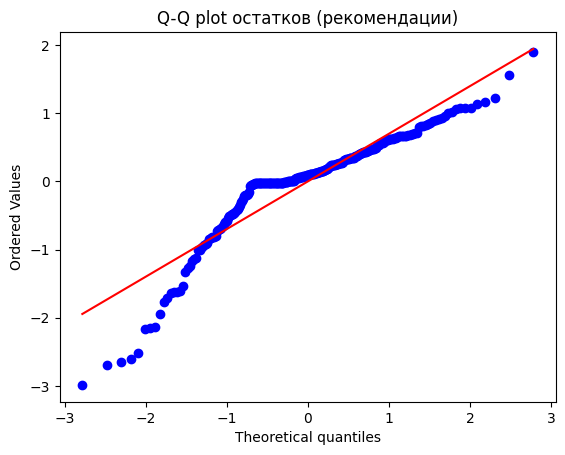

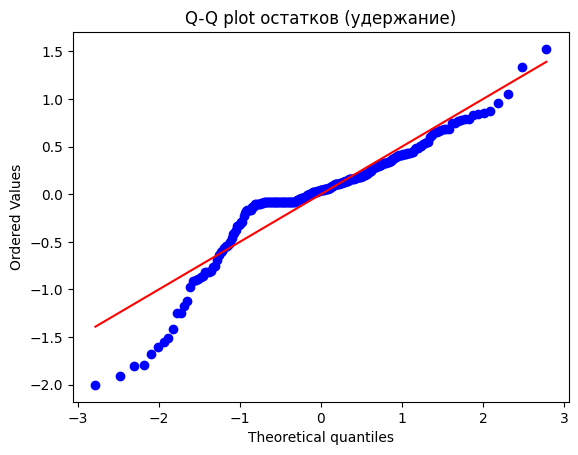

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(model_recom.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (рекомендации)")
plt.show()

stats.probplot(model_stay.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (удержание)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Матрица факторных нагрузок (oblimin):
                Фактор_1_obli  Фактор_2_obli  Фактор_3_obli  Фактор_4_obli  \
acad_scripts            0.298          0.190         -0.014          0.222   
acad_homework           0.123          0.127          0.055          0.289   
acad_logic              0.005          0.290          0.083          0.292   
tutor_speed             0.023         -0.052          0.875         -0.025   
tutor_feedback          0.242          0.175          0.194          0.023   
tutor_care              0.025          0.096          0.674          0.085   
vk_format               0.501          0.192         -0.066          0.007   
vk_quality              0.678         -0.032         -0.002          0.142   
vk_speed                0.901         -0.029          0.051         -0.045   
platf_stable            0.351          0.284          0.128         -0.030   
platf_easy              0.034          0.764         -0.082         -0.069   
platf_mobile            0.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


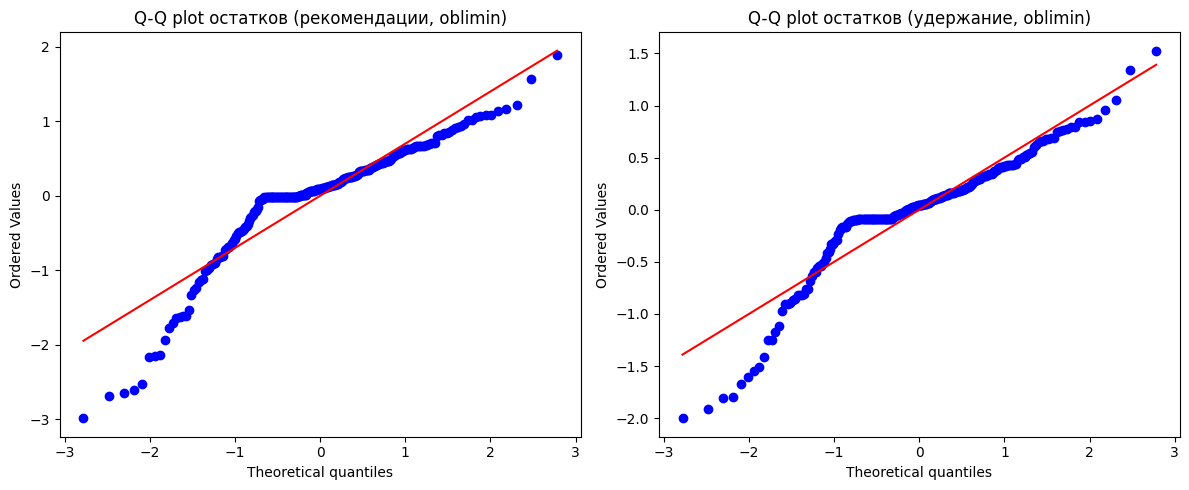


Breusch-Pagan test (рекомендации, oblimin): LM=38.640, p-value=0.000
Breusch-Pagan test (удержание, oblimin): LM=86.740, p-value=0.000

=== Сравнение моделей ===
Модель рекомендаций (varimax) R² = 0.291, JB = 184.3


AttributeError: 'OLSResults' object has no attribute 'jarque_bera'

In [ ]:
#Косоугольное вращение (oblimin) и регрессия
import pandas as pd
import numpy as np
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer
from scipy.stats import zscore
import matplotlib.pyplot as plt
import scipy.stats as stats

n_factors = 5
fa_obli = FactorAnalyzer(n_factors=n_factors, rotation='oblimin')
fa_obli.fit(items)

loadings_obli = pd.DataFrame(
    fa_obli.loadings_,
    index=items.columns,
    columns=[f'Фактор_{i+1}_obli' for i in range(n_factors)]
)
print("Матрица факторных нагрузок (oblimin):")
print(loadings_obli.round(3))

phi_matrix = pd.DataFrame(
    fa_obli.phi_,
    index=[f'Фактор_{i+1}_obli' for i in range(n_factors)],
    columns=[f'Фактор_{i+1}_obli' for i in range(n_factors)]
)
print("\nКорреляция между факторами (oblimin):")
print(phi_matrix.round(3))

factor_scores_obli = fa_obli.transform(items)
df_factors_obli = pd.DataFrame(
    factor_scores_obli,
    columns=[f'Фактор_{i+1}_obli' for i in range(n_factors)]
)

X_obli = df_factors_obli
y_recom = targets['target_recom']
y_stay = targets['target_stay']

X_obli_const = sm.add_constant(X_obli)

model_recom_obli = sm.OLS(y_recom, X_obli_const).fit()
print("\n=== Регрессия (oblimin): Рекомендации ===")
print(model_recom_obli.summary())

model_stay_obli = sm.OLS(y_stay, X_obli_const).fit()
print("\n=== Регрессия (oblimin): Удержание ===")
print(model_stay_obli.summary())

X_obli_std = X_obli.apply(zscore)
X_obli_std_const = sm.add_constant(X_obli_std)
y_recom_std = zscore(y_recom)
y_stay_std = zscore(y_stay)

model_recom_obli_std = sm.OLS(y_recom_std, X_obli_std_const).fit()
model_stay_obli_std = sm.OLS(y_stay_std, X_obli_std_const).fit()

beta_recom_obli = model_recom_obli_std.params[1:]  # без константы
beta_stay_obli = model_stay_obli_std.params[1:]

beta_obli_df = pd.DataFrame({
    'Фактор': [f'Фактор_{i+1}_obli' for i in range(n_factors)],
    'β (рекомендация)': beta_recom_obli.values,
    'β (удержание)': beta_stay_obli.values
})
print("\n--- Стандартизованные коэффициенты (oblimin) ---")
print(beta_obli_df.round(3))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
stats.probplot(model_recom_obli.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (рекомендации, oblimin)")

plt.subplot(1,2,2)
stats.probplot(model_stay_obli.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (удержание, oblimin)")
plt.tight_layout()
plt.show()

from statsmodels.stats.diagnostic import het_breuschpagan

bp_recom = het_breuschpagan(model_recom_obli.resid, model_recom_obli.model.exog)
print(f"\nBreusch-Pagan test (рекомендации, oblimin): LM={bp_recom[0]:.3f}, p-value={bp_recom[1]:.3f}")

bp_stay = het_breuschpagan(model_stay_obli.resid, model_stay_obli.model.exog)
print(f"Breusch-Pagan test (удержание, oblimin): LM={bp_stay[0]:.3f}, p-value={bp_stay[1]:.3f}")

print("\n=== Сравнение моделей ===")
print("Модель рекомендаций (varimax) R² = 0.291, JB = 184.3")
print(f"Модель рекомендаций (oblimin) R² = {model_recom_obli.rsquared:.3f}, JB = {model_recom_obli.jarque_bera:.3f}")
print("\nМодель удержания (varimax) R² = 0.349, JB = 146.2")
print(f"Модель удержания (oblimin) R² = {model_stay_obli.rsquared:.3f}, JB = {model_stay_obli.jarque_bera:.3f}")

Объяснённая дисперсия каждой компоненты:
PC1: 0.294
PC2: 0.087
PC3: 0.081
PC4: 0.078
PC5: 0.063
Суммарная объяснённая дисперсия: 0.602

Матрица нагрузок (PCA):
                  PC1    PC2    PC3    PC4    PC5
acad_scripts    0.271 -0.085 -0.160 -0.123  0.395
acad_homework   0.233 -0.153  0.009 -0.074  0.511
acad_logic      0.211  0.079  0.114  0.389 -0.249
tutor_speed     0.230 -0.114  0.491 -0.311 -0.169
tutor_feedback  0.233  0.022  0.015 -0.251  0.014
tutor_care      0.260 -0.065  0.462 -0.173 -0.210
vk_format       0.223  0.048 -0.406 -0.030 -0.373
vk_quality      0.270 -0.210 -0.321 -0.109 -0.240
vk_speed        0.307 -0.151 -0.302 -0.313 -0.052
platf_stable    0.268  0.110 -0.098 -0.231 -0.011
platf_easy      0.222  0.508 -0.110  0.136  0.070
platf_mobile    0.197  0.387 -0.066  0.113  0.349
info_org        0.256  0.359  0.229  0.035 -0.068
info_clear      0.267  0.186  0.150  0.208 -0.014
psy_stress      0.262 -0.330  0.130  0.253  0.146
psy_res         0.195 -0.139 -0.156  0.4

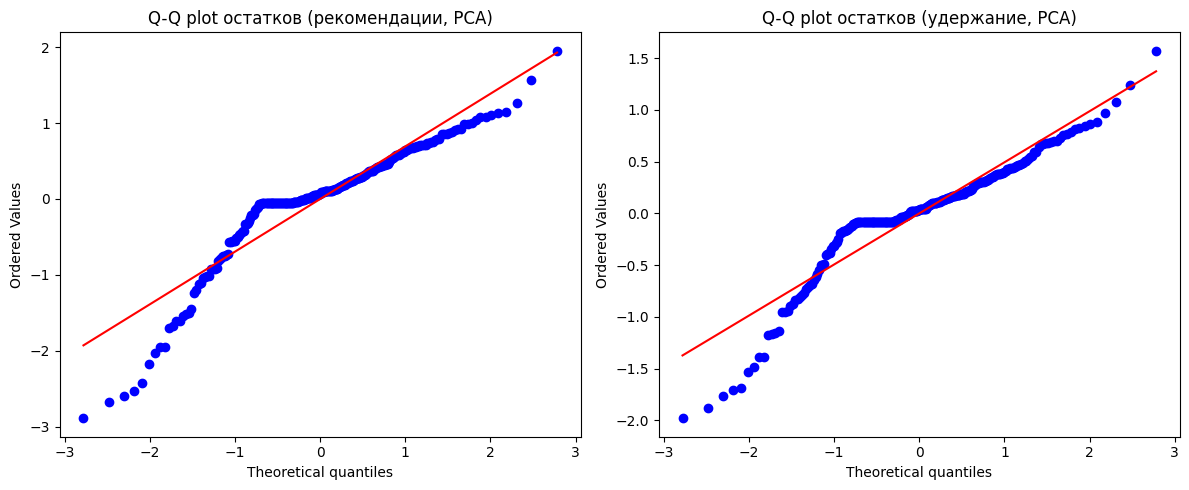


Breusch-Pagan test (рекомендации, PCA): LM=43.366, p-value=0.000
Breusch-Pagan test (удержание, PCA): LM=85.175, p-value=0.000


In [ ]:
# Метод главных компонент (PCA)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import statsmodels.api as sm
from scipy.stats import zscore
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

scaler = StandardScaler()
items_scaled = scaler.fit_transform(items)

pca = PCA(n_components=5)
principal_components = pca.fit_transform(items_scaled)

df_pca = pd.DataFrame(
    principal_components,
    columns=[f'PC{i+1}' for i in range(5)]
)

print("Объяснённая дисперсия каждой компоненты:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.3f}")
print(f"Суммарная объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.3f}")

loadings_pca = pd.DataFrame(
    pca.components_.T,
    index=items.columns,
    columns=[f'PC{i+1}' for i in range(5)]
)
print("\nМатрица нагрузок (PCA):")
print(loadings_pca.round(3))

X_pca = df_pca
y_recom = targets['target_recom']
y_stay = targets['target_stay']

X_pca_const = sm.add_constant(X_pca)

model_recom_pca = sm.OLS(y_recom, X_pca_const).fit()
print("\n=== Регрессия (PCA): Рекомендации ===")
print(model_recom_pca.summary())

model_stay_pca = sm.OLS(y_stay, X_pca_const).fit()
print("\n=== Регрессия (PCA): Удержание ===")
print(model_stay_pca.summary())

X_pca_std = X_pca.apply(zscore)
X_pca_std_const = sm.add_constant(X_pca_std)
y_recom_std = zscore(y_recom)
y_stay_std = zscore(y_stay)

model_recom_pca_std = sm.OLS(y_recom_std, X_pca_std_const).fit()
model_stay_pca_std = sm.OLS(y_stay_std, X_pca_std_const).fit()

beta_recom_pca = model_recom_pca_std.params[1:]
beta_stay_pca = model_stay_pca_std.params[1:]

beta_pca_df = pd.DataFrame({
    'Компонента': [f'PC{i+1}' for i in range(5)],
    'β (рекомендация)': beta_recom_pca.values,
    'β (удержание)': beta_stay_pca.values
})
print("\n--- Стандартизованные коэффициенты (PCA) ---")
print(beta_pca_df.round(3))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
stats.probplot(model_recom_pca.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (рекомендации, PCA)")
plt.subplot(1,2,2)
stats.probplot(model_stay_pca.resid, dist="norm", plot=plt)
plt.title("Q-Q plot остатков (удержание, PCA)")
plt.tight_layout()
plt.show()

bp_recom = het_breuschpagan(model_recom_pca.resid, model_recom_pca.model.exog)
print(f"\nBreusch-Pagan test (рекомендации, PCA): LM={bp_recom[0]:.3f}, p-value={bp_recom[1]:.3f}")
bp_stay = het_breuschpagan(model_stay_pca.resid, model_stay_pca.model.exog)
print(f"Breusch-Pagan test (удержание, PCA): LM={bp_stay[0]:.3f}, p-value={bp_stay[1]:.3f}")